# Business Sales Analytics Dashboard

## Problem Statement
In today’s competitive business environment, organizations need to make data-driven decisions to improve sales performance and profitability. However, raw sales data is often complex and unstructured, making it difficult to derive actionable insights.

This project analyzes Adidas US sales data to uncover trends, identify top-performing products, and build a predictive model for sales forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Adidas US Sales Datasets.xlsx", header=4)

# Automatically remove all unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.columns = df.columns.str.strip()

df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   str           
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[us]
 3   Region            9648 non-null   str           
 4   State             9648 non-null   str           
 5   City              9648 non-null   str           
 6   Product           9648 non-null   str           
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(2), str(6)
memory usage: 1.5 MB


,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


In [4]:
# Convert date column
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')

# Remove missing values
df.dropna(inplace=True)

df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

In [5]:
df['Month'] = df['Invoice Date'].dt.month
df['Year'] = df['Invoice Date'].dt.year
df['Profit Margin'] = df['Operating Profit'] / df['Total Sales']

In [6]:
print("Total Sales:", df['Total Sales'].sum())
print("Total Profit:", df['Operating Profit'].sum())
print("Total Units Sold:", df['Units Sold'].sum())
print("Average Profit:", df['Operating Profit'].mean())

Total Sales: 899902125.0
Total Profit: 332134761.45
Total Units Sold: 2478861
Average Profit: 34425.24476057214


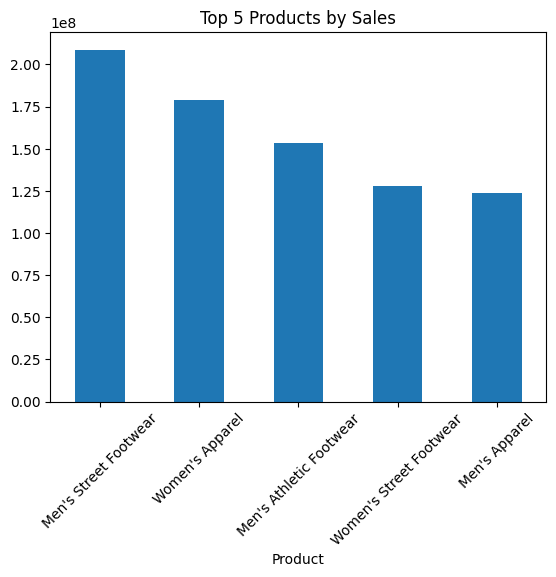

In [7]:
top_products = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)

top_products.head(5).plot(kind='bar')
plt.title('Top 5 Products by Sales')
plt.xticks(rotation=45)
plt.show()

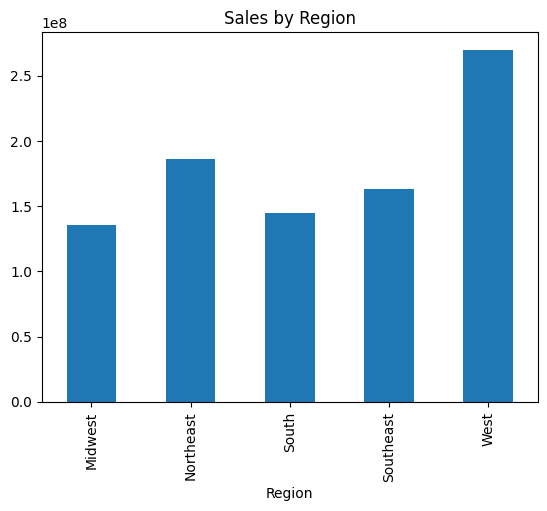

In [8]:
region_sales = df.groupby('Region')['Total Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.show()

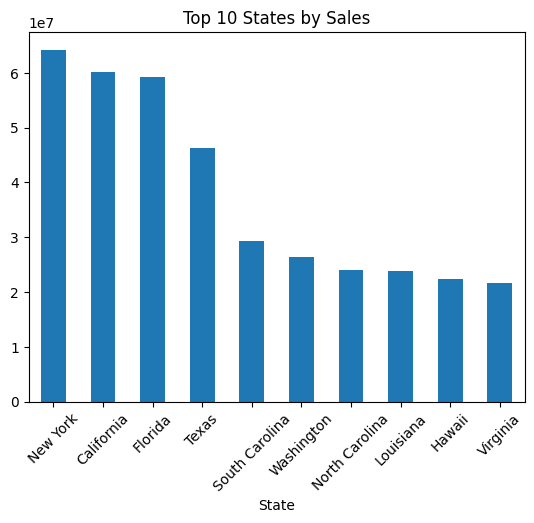

In [9]:
state_sales = df.groupby('State')['Total Sales'].sum().sort_values(ascending=False)

state_sales.head(10).plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xticks(rotation=45)
plt.show()

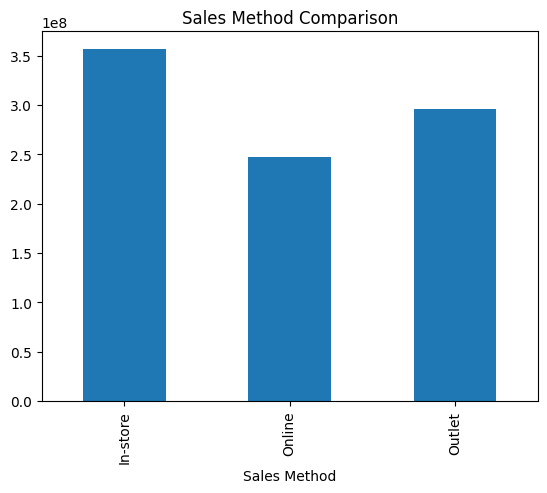

In [10]:
sales_method = df.groupby('Sales Method')['Total Sales'].sum()

sales_method.plot(kind='bar')
plt.title('Sales Method Comparison')
plt.show()

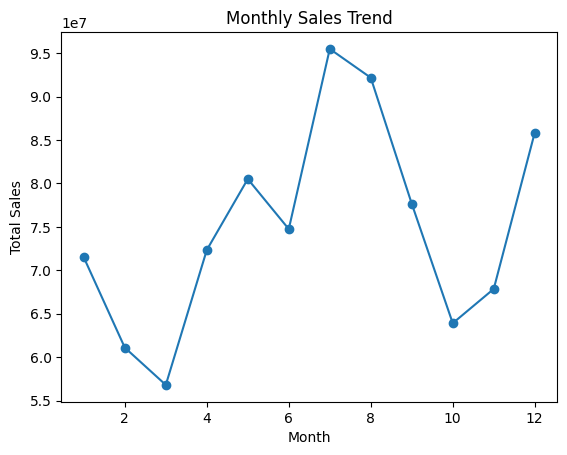

In [11]:
monthly_sales = df.groupby('Month')['Total Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

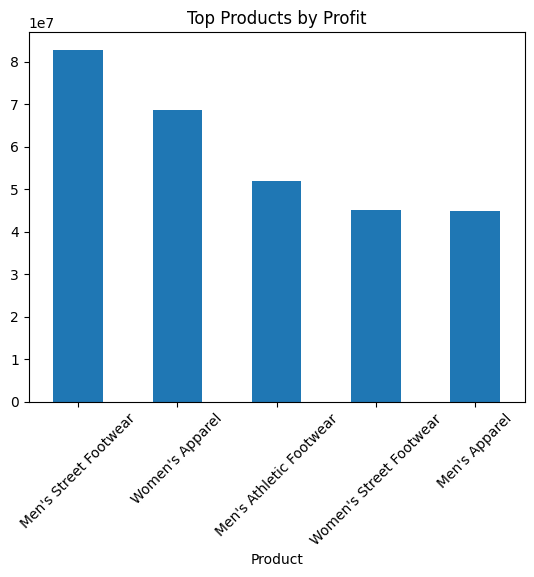

In [12]:
profit_product = df.groupby('Product')['Operating Profit'].sum().sort_values(ascending=False)

profit_product.head(5).plot(kind='bar')
plt.title('Top Products by Profit')
plt.xticks(rotation=45)
plt.show()

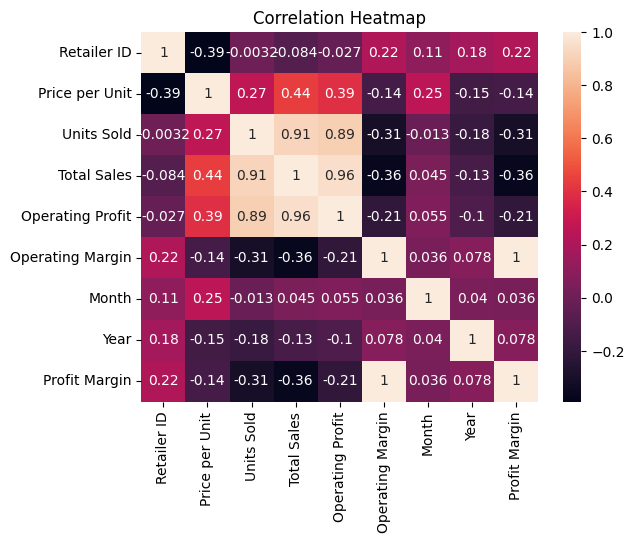

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = df[['Units Sold', 'Price per Unit']]
y = df['Total Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 39921.04680162804
R2 Score: 0.8597943867235793
